# Figure 3
## Selecting lncRNAs
### Author: Martin Loza
### Date: 25/12/09

We would like to explore the density of PCG-TFs around ncRNA's TSS. 
We will explore the different between lncRNA and ncRNAs

In [1]:
# Change R language to English
Sys.setenv(LANGUAGE = "en")

# Init
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(ggplot2)
    library(patchwork)
})

# Local variables 
seed = 777
date = "251209"

# Define colors for strand plots
red = "#E41A1C"
blue = "#377EB8"
# Define colors for gene types
green = "#4DAF4A"
purple = "#984EA3"
text_size = 18
width = 18.6
dot_size = 4
line_size = 1.5
dpi = 300

in_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/Data/Annotated_ncRNA_PCG_pairs/"
out_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/04_Figure_3/Plots/"

# Local Functions

# Simplified function to calculate density metrics for a given window size
calculate_density_metrics <- function(data, window_size, distance_column = "abs_strand_distance") {
    # Filter data within the window
    filtered_data <- data %>%
        filter(!!sym(distance_column) <= window_size)
    
    # Calculate counts and density, including ncrna_type
    metrics <- filtered_data %>%
        group_by(ncrna_strand, ncrna_type) %>%
        summarise(count = n(), .groups = 'drop') %>%
        mutate(
            window_size = window_size,
            strand = ifelse(ncrna_strand == 1, "Forward", "Reverse"),
            density = count / window_size
        )
    
    return(metrics)
}

### Load and setup the data

In [2]:
# Load the setup transcripts data
# We have different species, so let's create a list to store the data
data_list = list()

# Search for the available files
files <- list.files(in_dir)

# Load the data for each species
for (file in files) {
    # Remove the underscore and everything after it to get the species names
    species_name <- str_replace(file, "_.*", "")
    data_list[[species_name]] <- read.table(file.path(in_dir, file), sep = "\t", header = TRUE, 
                                            stringsAsFactors = FALSE, quote = "", 
                                            comment.char = "", fill = TRUE, row.names = NULL)
}

head(data_list[["human"]], 3)

,chromosome,ncRNA_id,ncrna_tss,ncrna_gene_name,ncrna_strand,gene_biotype,pcg_id,pcg_gene_name,pcg_tss,dna_distance,strand_distance,Family,is_TF
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<lgl>
1,19,ENST00000221567,54532791,,1,lncRNA,ENST00000590333,BRSK1,55282072,749281,749281,NA,FALSE
2,19,ENST00000221567,54532791,,1,lncRNA,ENST00000635964,C19orf85,55464751,931960,931960,NA,FALSE
3,19,ENST00000221567,54532791,,1,lncRNA,ENST00000346968,CACNG6,53992878,-539913,-539913,NA,FALSE


In [3]:
# Let's place an order in the plots
ordered_species <- c("human", "mouse")
# Arrange the data_list according to the ordered_species
data_selected_list <- data_list[ordered_species]

In [4]:
# remove data_list to avoid confusion
rm(data_list)

Let's label relationships as lncRNA or other ncRNA

In [5]:
# Add ncRNA type labeling for all species
for (species in names(data_selected_list)) {
    data_selected_list[[species]] <- data_selected_list[[species]] %>%
        mutate(ncrna_type = ifelse(gene_biotype == "lncRNA", "lncRNA", "other-ncRNA"))
}

head(data_selected_list[["human"]], 3)

,chromosome,ncRNA_id,ncrna_tss,ncrna_gene_name,ncrna_strand,gene_biotype,pcg_id,pcg_gene_name,pcg_tss,dna_distance,strand_distance,Family,is_TF,ncrna_type
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<lgl>,<chr>
1,19,ENST00000221567,54532791,,1,lncRNA,ENST00000590333,BRSK1,55282072,749281,749281,NA,FALSE,lncRNA
2,19,ENST00000221567,54532791,,1,lncRNA,ENST00000635964,C19orf85,55464751,931960,931960,NA,FALSE,lncRNA
3,19,ENST00000221567,54532791,,1,lncRNA,ENST00000346968,CACNG6,53992878,-539913,-539913,NA,FALSE,lncRNA


In this case, we will focus only on PCGs annotated as TF

In [6]:
cat("Number of human PCGs:", length(unique(data_selected_list[["human"]]$pcg_gene_name)), "\n")
cat("Number of human TF-PCGs :", data_selected_list[["human"]] %>% filter(is_TF) %>% pull(pcg_gene_name) %>% unique() %>% length(), "\n")

cat("Number of mouse PCGs:", length(unique(data_selected_list[["mouse"]]$pcg_gene_name)), "\n")
cat("Number of mouse TF-PCGs :", data_selected_list[["mouse"]] %>% filter(is_TF) %>% pull(pcg_gene_name) %>% unique() %>% length(), "\n")

Number of human PCGs: 19342 
Number of human TF-PCGs : 1629 
Number of mouse PCGs: 21491 
Number of mouse TF-PCGs : 1563 


### Selection of the thresholds

Let's try to analyse the density of PCG around ncRNA's TSS with different width thresholds.

In this case, let's get and absolute distance to avoid any effects from upstream and downstream location

In [7]:
# Add absolute distance column
for (species in names(data_selected_list)) {
    data_selected_list[[species]] <- data_selected_list[[species]] %>%
        mutate(abs_strand_distance = abs(strand_distance))
}

In [8]:
# Define the window sizes to compare (in bp)
window_sizes <- c(1000, 5000, 10000, 50000, 100000, 500000, 1000000)

In [9]:
# Separate data into TF and non-TF sets
data_TF_list <- list()
data_nonTF_list <- list()

for (species in names(data_selected_list)) {
    data_TF_list[[species]] <- data_selected_list[[species]] %>% filter(is_TF)
    data_nonTF_list[[species]] <- data_selected_list[[species]] %>% filter(!is_TF)
}

# Calculate density metrics for TF genes
all_density_TF <- list()

for (species in names(data_TF_list)) {
    species_metrics <- data.frame()
    
    for (ws in window_sizes) {
        temp_metrics <- calculate_density_metrics(data_TF_list[[species]], window_size = ws)
        species_metrics <- rbind(species_metrics, temp_metrics)
    }
    
    species_metrics$species <- species
    species_metrics$gene_type <- "TF"
    all_density_TF[[species]] <- species_metrics
}

# Calculate density metrics for non-TF genes
all_density_nonTF <- list()

for (species in names(data_nonTF_list)) {
    species_metrics <- data.frame()
    
    for (ws in window_sizes) {
        temp_metrics <- calculate_density_metrics(data_nonTF_list[[species]], window_size = ws)
        species_metrics <- rbind(species_metrics, temp_metrics)
    }
    
    species_metrics$species <- species
    species_metrics$gene_type <- "non-TF"
    all_density_nonTF[[species]] <- species_metrics
}

# Combine TF and non-TF metrics
density_TF_df <- do.call(rbind, all_density_TF)
density_nonTF_df <- do.call(rbind, all_density_nonTF)
density_df <- rbind(density_TF_df, density_nonTF_df)
rownames(density_df) <- NULL

head(density_df, 3)

ncrna_strand,ncrna_type,count,window_size,strand,density,species,gene_type
<int>,<chr>,<int>,<dbl>,<chr>,<dbl>,<chr>,<chr>
-1,lncRNA,17738,1000,Reverse,17.738,human,TF
-1,other-ncRNA,41,1000,Reverse,0.041,human,TF
1,lncRNA,19990,1000,Forward,19.990,human,TF


### Main Figure: TF vs non-TF density comparison

In [10]:
# Aggregate density across strands for simplified comparison
density_combined_df <- density_df %>%
    group_by(species, window_size, gene_type, ncrna_type) %>%
    summarise(
        total_count = sum(count),
        combined_density = total_count / window_size,
        .groups = 'drop'
    )

# Remove duplicated rows if any
density_combined_df <- density_combined_df %>% distinct()

head(density_combined_df)

Warning message:
“Returning more (or less) than 1 row per `summarise()` group was deprecated in
dplyr 1.1.0.
ℹ Please use `reframe()` instead.
ℹ When switching from `summarise()` to `reframe()`, remember that `reframe()`
  always returns an ungrouped data frame and adjust accordingly.”


species,window_size,gene_type,ncrna_type,total_count,combined_density
<chr>,<dbl>,<chr>,<chr>,<int>,<dbl>
human,1000,TF,lncRNA,37728,37.7280
human,1000,TF,other-ncRNA,187,0.1870
human,1000,non-TF,lncRNA,29952,29.9520
human,1000,non-TF,other-ncRNA,438,0.4380
human,5000,TF,lncRNA,47508,9.5016
human,5000,TF,other-ncRNA,826,0.1652


In [13]:
# Perform statistical testing for TF vs non-TF at each window size and ncRNA type
pvalue_results <- list()

for (sp in unique(density_combined_df$species)) {
    for (ws in window_sizes) {
        for (ncrna_t in c("lncRNA", "other-ncRNA")) {
            # Get the raw data for this species, window, and ncRNA type
            tf_data <- data_TF_list[[sp]] %>% 
                filter(abs_strand_distance <= ws, ncrna_type == ncrna_t)
            nontf_data <- data_nonTF_list[[sp]] %>% 
                filter(abs_strand_distance <= ws, ncrna_type == ncrna_t)
            
            # Get counts
            tf_count <- nrow(tf_data)
            nontf_count <- nrow(nontf_data)
            
            # Calculate densities
            tf_density <- tf_count / ws
            nontf_density <- nontf_count / ws
            
            # Get total genes for this ncRNA type
            total_genes_tf <- data_TF_list[[sp]] %>% filter(ncrna_type == ncrna_t) %>% nrow()
            total_genes_nontf <- data_nonTF_list[[sp]] %>% filter(ncrna_type == ncrna_t) %>% nrow()
            
            # Skip if no data
            if (total_genes_tf == 0 || total_genes_nontf == 0) next
            
            # Create contingency table: [in_window, not_in_window] x [TF, non-TF]
            cont_table <- matrix(c(tf_count, total_genes_tf - tf_count,
                                   nontf_count, total_genes_nontf - nontf_count),
                                 nrow = 2, byrow = FALSE)
            
            test_result <- chisq.test(cont_table)
            
            pvalue_results[[length(pvalue_results) + 1]] <- data.frame(
                species = sp,
                window_size = ws,
                ncrna_type = ncrna_t,
                pvalue = test_result$p.value,
                tf_density = tf_density,
                nontf_density = nontf_density
            )
        }
    }
}

pvalue_df <- do.call(rbind, pvalue_results)

# Apply FDR correction (Benjamini-Hochberg)
pvalue_df <- pvalue_df %>%
    mutate(
        fdr = p.adjust(pvalue, method = "fdr"),
        significance = case_when(
            fdr < 0.001 ~ "***",
            fdr < 0.01 ~ "**",
            fdr < 0.05 ~ "*",
            TRUE ~ ""
        )
    )

head(pvalue_df)

Warning message in chisq.test(cont_table):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(cont_table):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(cont_table):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(cont_table):
“Chi-squared approximation may be incorrect”


,species,window_size,ncrna_type,pvalue,tf_density,nontf_density,fdr,significance
,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,human,1000,lncRNA,0.000000e+00,37.7280,29.9520,0.000000e+00,***
2,human,1000,other-ncRNA,4.552322e-01,0.1870,0.4380,4.750249e-01,
3,human,5000,lncRNA,0.000000e+00,9.5016,7.8340,0.000000e+00,***
4,human,5000,other-ncRNA,2.432460e-10,0.1652,0.3164,3.243280e-10,***
5,human,10000,lncRNA,0.000000e+00,5.5454,5.0125,0.000000e+00,***
6,human,10000,other-ncRNA,2.129861e-26,0.1535,0.2759,3.194792e-26,***


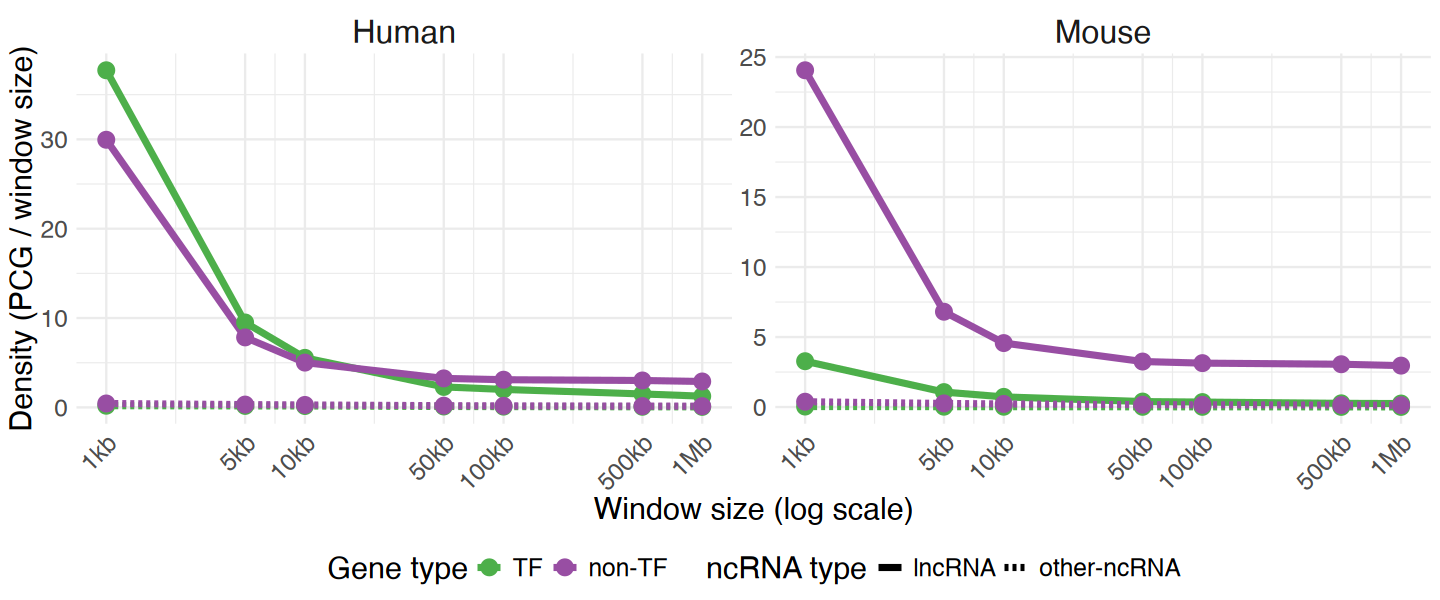

In [14]:
# Visualize TF vs non-TF comparison by ncRNA type
options(repr.plot.width=12, repr.plot.height=5)

p_density_combined <- density_combined_df %>%
    ggplot(aes(x = window_size / 1000, y = combined_density, 
               color = gene_type, linetype = ncrna_type, 
               group = interaction(gene_type, ncrna_type))) +
    geom_line(linewidth = line_size) +
    geom_point(size = dot_size) +
    facet_wrap(~str_to_title(species), scales = "free_y", ncol = 2) +
    scale_color_manual(values = c("TF" = green, "non-TF" = purple)) +
    scale_linetype_manual(values = c("lncRNA" = "solid", "other-ncRNA" = "dashed")) +
    scale_x_log10(breaks = window_sizes / 1000, 
                  labels = c("1kb", "5kb", "10kb", "50kb", "100kb", "500kb", "1Mb")) +
    theme_minimal() +
    labs(x = "Window size (log scale)",
         y = "Density (PCG / window size)",
         color = "Gene type",
         linetype = "ncRNA type") +
    theme(text = element_text(size = text_size),
          strip.text = element_text(size = text_size + 1),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "bottom")

p_density_combined

In [ ]:
# Save the main figure
ggsave(filename = file.path(out_dir, paste0("Sup_Fig_lncRNA_vs_other_ncRNA_with_TF_density_", date, ".pdf")),
    plot = p_density_combined, 
    width = width * 0.6, height = 5.0, units = "in", dpi = dpi)

### Plot comparing lncRNA vs other-ncRNA without TF annotation

In [15]:
# Create a simplified comparison: lncRNA vs other-ncRNA (combining TF and non-TF)
density_ncrna_only <- density_combined_df %>%
    group_by(species, window_size, ncrna_type) %>%
    summarise(
        total_count = sum(total_count),
        combined_density = total_count / window_size,
        .groups = 'drop'
    )

head(density_ncrna_only)

Warning message:
“Returning more (or less) than 1 row per `summarise()` group was deprecated in
dplyr 1.1.0.
ℹ Please use `reframe()` instead.
ℹ When switching from `summarise()` to `reframe()`, remember that `reframe()`
  always returns an ungrouped data frame and adjust accordingly.”


species,window_size,ncrna_type,total_count,combined_density
<chr>,<dbl>,<chr>,<int>,<dbl>
human,1000,lncRNA,67680,67.6800
human,1000,lncRNA,67680,67.6800
human,1000,other-ncRNA,625,0.6250
human,1000,other-ncRNA,625,0.6250
human,5000,lncRNA,86678,17.3356
human,5000,lncRNA,86678,17.3356


In [21]:
# Perform statistical testing for lncRNA vs other-ncRNA at each window size
pvalue_ncrna_results <- list()

for (sp in unique(density_ncrna_only$species)) {
    for (ws in window_sizes) {
        # Get the raw data for this species and window
        lncrna_data <- data_selected_list[[sp]] %>% 
            filter(abs_strand_distance <= ws, ncrna_type == "lncRNA")
        other_ncrna_data <- data_selected_list[[sp]] %>% 
            filter(abs_strand_distance <= ws, ncrna_type == "other-ncRNA")
        
        # Get counts
        lncrna_count <- nrow(lncrna_data)
        other_ncrna_count <- nrow(other_ncrna_data)
        
        # Calculate densities
        lncrna_density <- lncrna_count / ws
        other_ncrna_density <- other_ncrna_count / ws
        
        # Get total genes for each ncRNA type
        total_genes_lncrna <- data_selected_list[[sp]] %>% filter(ncrna_type == "lncRNA") %>% nrow()
        total_genes_other <- data_selected_list[[sp]] %>% filter(ncrna_type == "other-ncRNA") %>% nrow()
        
        # Skip if no data
        if (total_genes_lncrna == 0 || total_genes_other == 0) next
        
        # Create contingency table: [in_window, not_in_window] x [lncRNA, other-ncRNA]
        cont_table <- matrix(c(lncrna_count, total_genes_lncrna - lncrna_count,
                               other_ncrna_count, total_genes_other - other_ncrna_count),
                             nrow = 2, byrow = FALSE)
        
        test_result <- chisq.test(cont_table)
        
        pvalue_ncrna_results[[length(pvalue_ncrna_results) + 1]] <- data.frame(
            species = sp,
            window_size = ws,
            pvalue = test_result$p.value,
            lncrna_density = lncrna_density,
            other_ncrna_density = other_ncrna_density
        )
    }
}

pvalue_ncrna_df <- do.call(rbind, pvalue_ncrna_results)

# Apply FDR correction (Benjamini-Hochberg)
pvalue_ncrna_df <- pvalue_ncrna_df %>%
    mutate(
        fdr = p.adjust(pvalue, method = "fdr"),
        significance = case_when(
            fdr < 0.001 ~ "***",
            fdr < 0.01 ~ "**",
            fdr < 0.05 ~ "*",
            TRUE ~ ""
        )
    )

head(pvalue_ncrna_df)

Warning message in chisq.test(cont_table):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(cont_table):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(cont_table):
“Chi-squared approximation may be incorrect”


,species,window_size,pvalue,lncrna_density,other_ncrna_density,fdr,significance
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,human,1e+03,0.000000e+00,67.68000,0.625000,0.000000e+00,***
2,human,5e+03,1.239019e-146,17.33560,0.481600,7.434116e-146,***
3,human,1e+04,6.782781e-20,10.55790,0.429400,8.139338e-20,***
4,human,5e+04,1.194438e-59,5.53428,0.295760,3.583314e-59,***
5,human,1e+05,2.194352e-44,5.10754,0.259770,3.761746e-44,***
6,human,5e+05,7.319839e-23,4.51612,0.215774,9.759786e-23,***


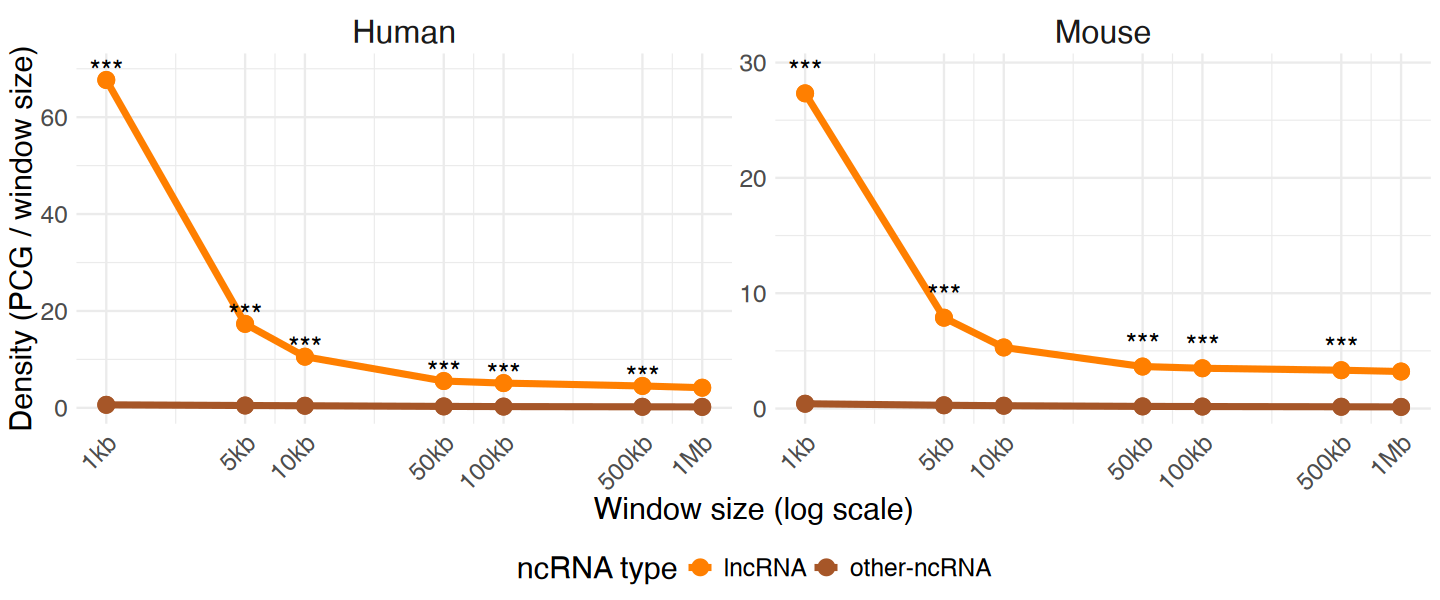

In [22]:
# Visualize lncRNA vs other-ncRNA comparison (without TF/non-TF distinction)
options(repr.plot.width=12, repr.plot.height=5)

# Merge significance information with density data
density_ncrna_with_sig <- density_ncrna_only %>%
    left_join(pvalue_ncrna_df %>% select(species, window_size, significance), 
              by = c("species", "window_size"))

# Calculate y position for significance labels (above the higher point)
density_max_per_window <- density_ncrna_with_sig %>%
    group_by(species, window_size) %>%
    summarise(
        max_density = max(combined_density),
        significance = first(significance[significance != ""]),
        .groups = 'drop'
    ) %>%
    filter(!is.na(significance) & significance != "")

p_density_ncrna <- density_ncrna_only %>%
    ggplot(aes(x = window_size / 1000, y = combined_density, color = ncrna_type, group = ncrna_type)) +
    geom_line(linewidth = line_size) +
    geom_point(size = dot_size) +
    # Add significance labels
    geom_text(data = density_max_per_window,
              aes(x = window_size / 1000, y = max_density + 2, label = significance),
              inherit.aes = FALSE, size = 6, color = "black") +
    facet_wrap(~str_to_title(species), scales = "free_y", ncol = 2) +
    scale_color_manual(values = c("lncRNA" = "#FF7F00", "other-ncRNA" = "#A65628")) +
    scale_x_log10(breaks = window_sizes / 1000, 
                  labels = c("1kb", "5kb", "10kb", "50kb", "100kb", "500kb", "1Mb")) +
    theme_minimal() +
    labs(x = "Window size (log scale)",
         y = "Density (PCG / window size)",
         color = "ncRNA type") +
    theme(text = element_text(size = text_size),
          strip.text = element_text(size = text_size + 1),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "bottom")

p_density_ncrna

In [23]:
# Save the lncRNA vs other-ncRNA comparison plot
ggsave(filename = file.path(out_dir, paste0("Fig_3_lncRNA_vs_other_ncRNA_density_", date, ".pdf")),
    plot = p_density_ncrna, 
    width = width * 0.6, height = 5.0, units = "in", dpi = dpi)

In [57]:
# Create normalized version for lncRNA vs other-ncRNA comparison
# Apply min-max normalization within each species and ncRNA type
density_ncrna_normalized <- density_ncrna_only %>%
    group_by(species, ncrna_type) %>%
    mutate(
        normalized_density = (combined_density - min(combined_density)) / (max(combined_density) - min(combined_density))
    ) %>%
    ungroup()

head(density_ncrna_normalized)

species,window_size,ncrna_type,total_count,combined_density,normalized_density
<chr>,<dbl>,<chr>,<int>,<dbl>,<dbl>
human,1000,lncRNA,67680,67.6800,1.0000000
human,1000,lncRNA,67680,67.6800,1.0000000
human,1000,other-ncRNA,625,0.6250,1.0000000
human,1000,other-ncRNA,625,0.6250,1.0000000
human,5000,lncRNA,86678,17.3356,0.2074785
human,5000,lncRNA,86678,17.3356,0.2074785


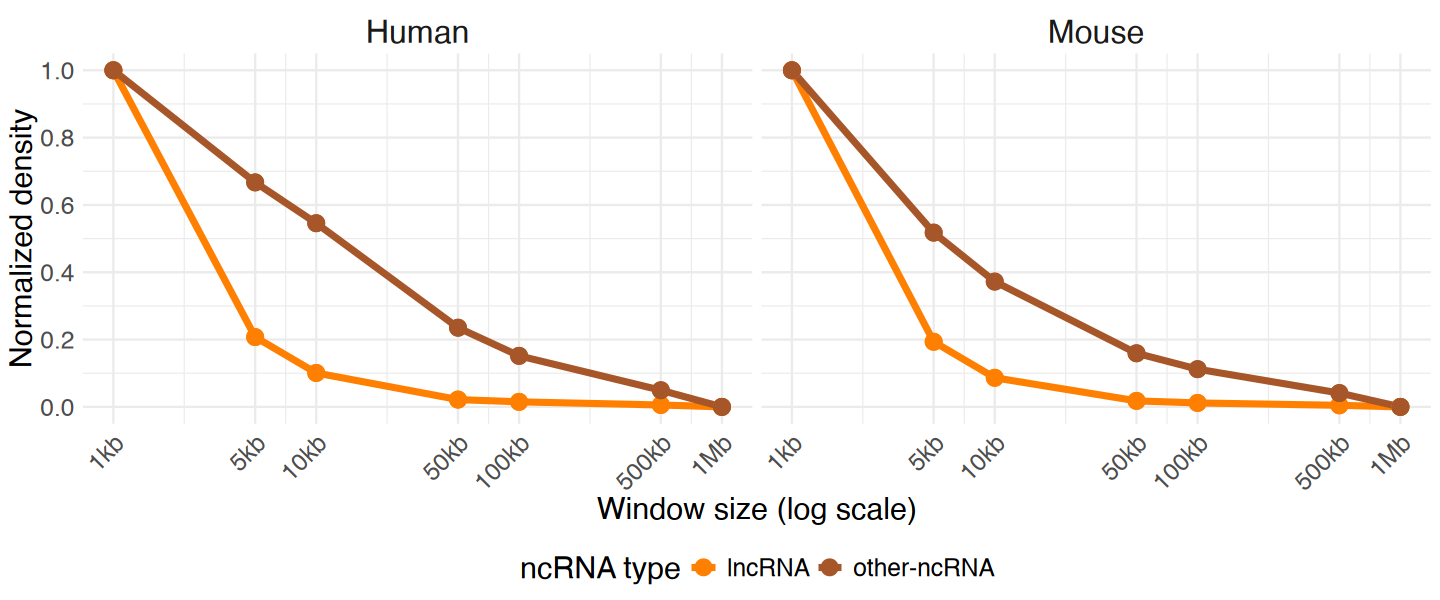

In [58]:
# Visualize normalized lncRNA vs other-ncRNA comparison
options(repr.plot.width=12, repr.plot.height=5)

p_density_ncrna_normalized <- density_ncrna_normalized %>%
    ggplot(aes(x = window_size / 1000, y = normalized_density, 
               color = ncrna_type, group = ncrna_type)) +
    geom_line(linewidth = line_size) +
    geom_point(size = dot_size) +
    facet_wrap(~str_to_title(species), ncol = 2) +
    scale_color_manual(values = c("lncRNA" = "#FF7F00", "other-ncRNA" = "#A65628")) +
    scale_x_log10(breaks = window_sizes / 1000, 
                  labels = c("1kb", "5kb", "10kb", "50kb", "100kb", "500kb", "1Mb")) +
    scale_y_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.2)) +
    theme_minimal() +
    labs(x = "Window size (log scale)",
         y = "Normalized density",
         color = "ncRNA type") +
    theme(text = element_text(size = text_size),
          strip.text = element_text(size = text_size + 1),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "bottom")

p_density_ncrna_normalized

In [59]:
# Save the normalized lncRNA vs other-ncRNA comparison plot
ggsave(filename = file.path(out_dir, paste0("Sup_Fig_lncRNA_vs_other_ncRNA_normalized_density_", date, ".pdf")),
    plot = p_density_ncrna_normalized, 
    width = width * 0.6, height = 5.0, units = "in", dpi = dpi)